# Chain Walk Experiments
Comparing RPI vs CRPI with Linear and Polynomial Function Approximation

In [5]:
import numpy as np
from environments.chain_walk import ChainWalkEnv
from function_approximation.linear_fa import LinearFA
from function_approximation.polynomial_fa import PolynomialFA
from utils import run_experiment, run_polynomial_sweep

In [6]:
# Environment Setup
env = ChainWalkEnv(N=50, p=0.9)

# Get state/action dimensions for FA
P, R = env.get_mdp_matrices()
n_states = P.shape[0]
n_actions = P.shape[1]

# Hyperparameters
gamma = 0.9
iters = 50
n_seeds = 10

print(f"Environment: Chain Walk")
print(f"States: {n_states}, Actions: {n_actions}")
print(f"Gamma: {gamma}, Iterations: {iters}, Seeds: {n_seeds}")

Environment: Chain Walk
States: 50, Actions: 2
Gamma: 0.9, Iterations: 50, Seeds: 10


## Section 1: Linear Function Approximation

Running 10 seeds for Linear FA...


/home/sans/.local/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Plot saved to: plots/Linear_FA/RPI_vs_CRPI_Linear_FA_20260307_012235.png


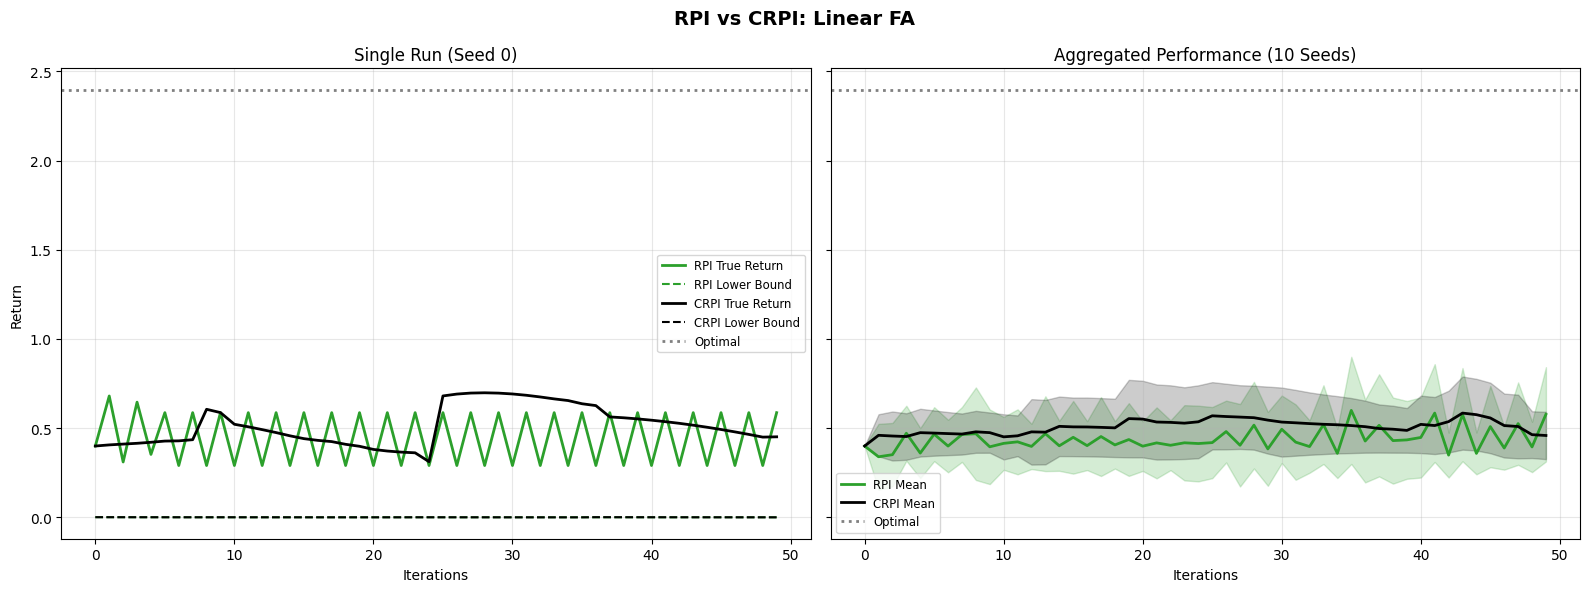

,Algorithm,AUC (mean ± std),Terminal Perf. (mean ± std)
0,RPI,21.5 ± 3.7,0.58 ± 0.26
1,CRPI,25.0 ± 6.0,0.46 ± 0.13


In [7]:
# Linear FA Experiment
d_features = 10

linear_results = run_experiment(
    env=env,
    fa_class=LinearFA,
    gamma=gamma,
    iters=iters,
    n_seeds=n_seeds,
    fa_params={'n_states': n_states, 'n_actions': n_actions, 'd_features': d_features},
    title_suffix="Linear FA",
    verbose=True
)

## Section 2: Polynomial Function Approximation


POLYNOMIAL DEGREE: 2


/home/sans/.local/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/sans/.local/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/sans/.local/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/sans/.local/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/sans/.local/lib/python3.10/site-packages/cvxpy

Plot saved to: plots/polynomial_sweep/Polynomial_Degree_2_20260307_012247.png


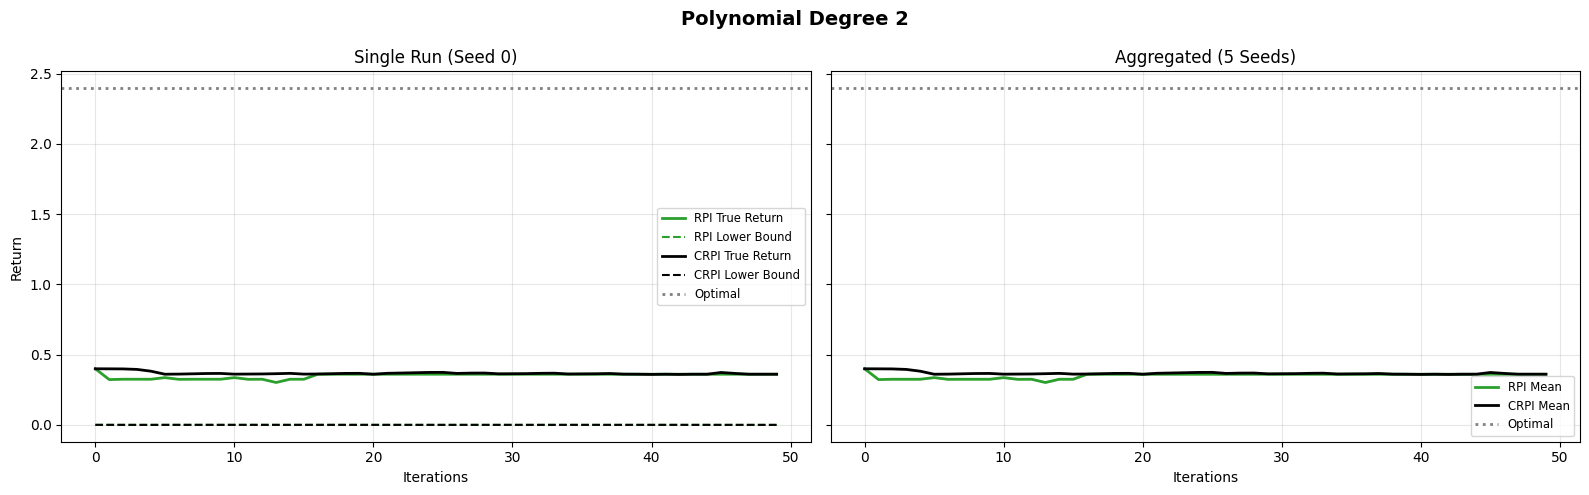

,Algorithm,AUC (mean ± std),Terminal Perf. (mean ± std)
0,RPI,17.2 ± 0.0,0.36 ± 0.00
1,CRPI,18.0 ± 0.0,0.36 ± 0.00



POLYNOMIAL DEGREE: 3


/home/sans/.local/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/sans/.local/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/sans/.local/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/sans/.local/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [ ]:
# Polynomial FA Experiment - Sweep across degrees
degrees = [2, 3, 4, 5, 6]
poly_n_seeds = 5  # Fewer seeds for polynomial sweep (more expensive)

poly_results, poly_summary = run_polynomial_sweep(
    env=env,
    poly_fa_class=PolynomialFA,
    degrees=degrees,
    gamma=gamma,
    iters=iters,
    n_seeds=poly_n_seeds,
    base_fa_params={'n_states': n_states, 'n_actions': n_actions, 'd_features': 3},
    verbose=True
)